In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import statsmodels.api as sm

In [2]:
df = pd.read_csv('/Users/kyleshare/School/Occidental/Computational Biology/Final Project/Data/GCST90297790.tsv', sep='\t')

In [3]:
df['-logp'] = - np.log10(df['p_value'])
df

,chromosome,base_pair_location,effect_allele,other_allele,beta,standard_error,effect_allele_frequency,p_value,rs_id,info,-logp
0,1,49298,T,C,-0.286429,0.278038,0.00682,0.302937,rs10399793,0.04320,0.518648
1,1,54353,A,C,-0.546315,1.173490,0.00971,0.641545,rs140052487,0.00161,0.192773
2,1,54712,C,T,-1.266810,1.517310,0.01544,0.403780,rs773293602,0.00048,0.393855
3,1,55326,C,T,2.805280,2.578980,0.04431,0.276720,rs3107975,0.00004,0.557959
4,1,58814,A,G,-0.433076,0.430802,0.00370,0.314774,rs114420996,1.00000,0.502001
...,...,...,...,...,...,...,...,...,...,...,...
6788335,9,138214317,T,A,0.013209,0.019904,0.35061,0.506948,rs141983864,0.24388,0.295037
6788336,9,138214775,A,G,-0.038142,0.056411,0.09306,0.498959,rs11559363,0.07919,0.301935
6788337,9,138217446,T,C,-0.009055,0.020615,0.28578,0.660479,rs11562371,0.25138,0.180141
6788338,9,138217672,C,T,-0.020562,0.022061,0.31697,0.351318,rs11137421,0.20577,0.454300


In [4]:
df['SNP number'] = df.index
df

,chromosome,base_pair_location,effect_allele,other_allele,beta,standard_error,effect_allele_frequency,p_value,rs_id,info,-logp,SNP number
0,1,49298,T,C,-0.286429,0.278038,0.00682,0.302937,rs10399793,0.04320,0.518648,0
1,1,54353,A,C,-0.546315,1.173490,0.00971,0.641545,rs140052487,0.00161,0.192773,1
2,1,54712,C,T,-1.266810,1.517310,0.01544,0.403780,rs773293602,0.00048,0.393855,2
3,1,55326,C,T,2.805280,2.578980,0.04431,0.276720,rs3107975,0.00004,0.557959,3
4,1,58814,A,G,-0.433076,0.430802,0.00370,0.314774,rs114420996,1.00000,0.502001,4
...,...,...,...,...,...,...,...,...,...,...,...,...
6788335,9,138214317,T,A,0.013209,0.019904,0.35061,0.506948,rs141983864,0.24388,0.295037,6788335
6788336,9,138214775,A,G,-0.038142,0.056411,0.09306,0.498959,rs11559363,0.07919,0.301935,6788336
6788337,9,138217446,T,C,-0.009055,0.020615,0.28578,0.660479,rs11562371,0.25138,0.180141,6788337
6788338,9,138217672,C,T,-0.020562,0.022061,0.31697,0.351318,rs11137421,0.20577,0.454300,6788338


In [5]:
running_pos = 0
cumulative_pos = []
for chrom, group_df in df.groupby('chromosome'):
    cumulative_pos.append(group_df['base_pair_location'] + running_pos)
    running_pos += group_df['base_pair_location'].max()
df['cumulative_pos'] = pd.concat(cumulative_pos)

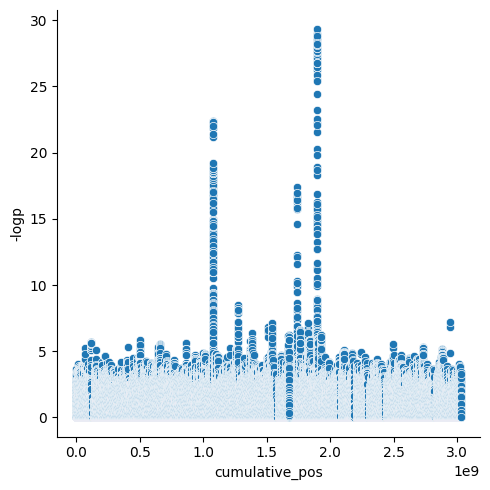

In [6]:
sns.relplot(
    data = df,
    x = 'cumulative_pos',
    y = '-logp'
)
plt.show()


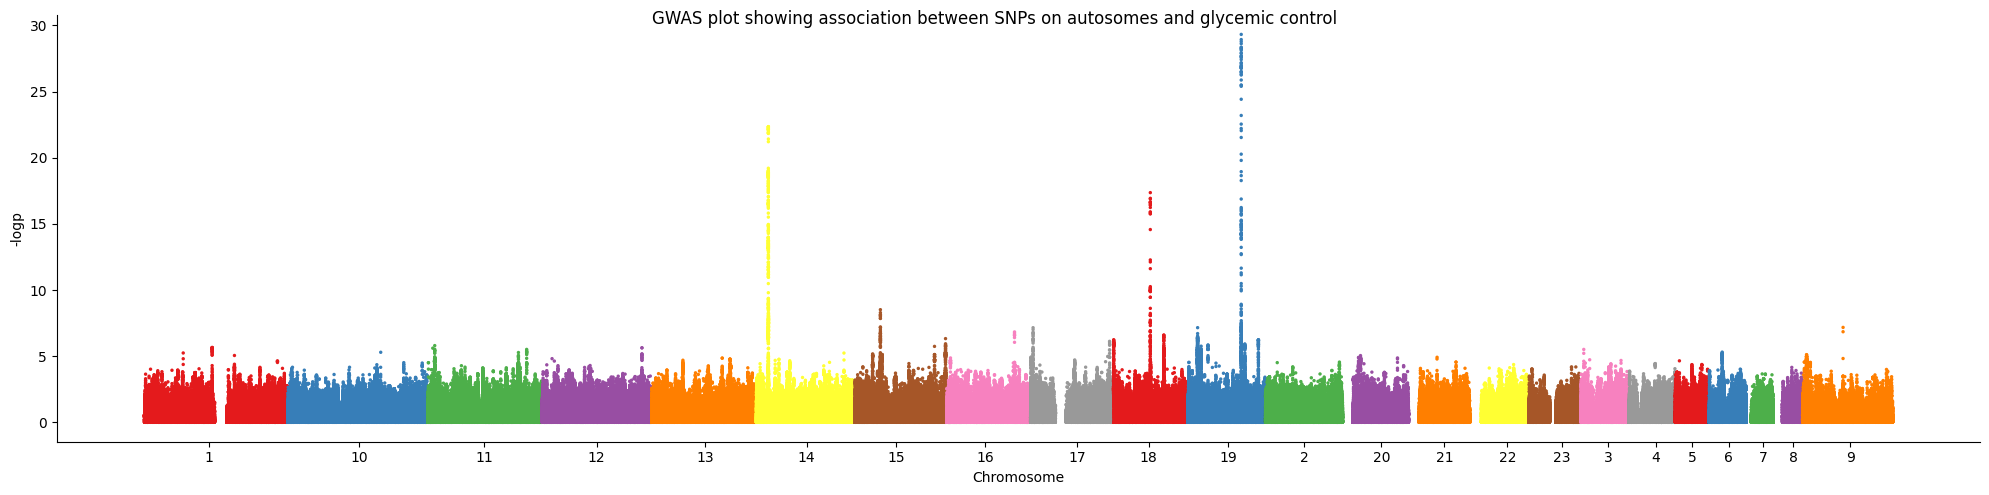

In [7]:
g = sns.relplot(
    data = df,
    x = 'cumulative_pos',
    y = '-logp',
    aspect = 4,
    hue = df['chromosome'],
    palette = 'Set1',
    linewidth=0,
    s=6,
    legend=None
)
g.ax.set_xlabel('Chromosome')
g.ax.set_xticks(df.groupby('chromosome')['cumulative_pos'].median())
g.ax.set_xticklabels(df['chromosome'].unique())
g.fig.suptitle('GWAS plot showing association between SNPs on autosomes and glycemic control')
plt.show()

## Problem with Manhattan Plot

Up to this point, I've been able to follow the code essentially as it was written for Lab 5 during our GWAS analysis of risky behavior. Here, though, I run into a problem because the data from the .tsv file is not sorted by chromosome as our previous data was. Instead, the data is lexicographically sorted where 10-19 all come before chromosome 2.
___
##### To fix this, I will re-sort the data by their numeric chromosome values rather than lexicographic sorting

In [8]:
df = df.sort_values(['chromosome', 'base_pair_location'])
df

,chromosome,base_pair_location,effect_allele,other_allele,beta,standard_error,effect_allele_frequency,p_value,rs_id,info,-logp,SNP number,cumulative_pos
0,1,49298,T,C,-0.286429,0.278038,0.00682,0.302937,rs10399793,0.04320,0.518648,0,49298
1,1,54353,A,C,-0.546315,1.173490,0.00971,0.641545,rs140052487,0.00161,0.192773,1,54353
2,1,54712,C,T,-1.266810,1.517310,0.01544,0.403780,rs773293602,0.00048,0.393855,2,54712
3,1,55326,C,T,2.805280,2.578980,0.04431,0.276720,rs3107975,0.00004,0.557959,3,55326
4,1,58814,A,G,-0.433076,0.430802,0.00370,0.314774,rs114420996,1.00000,0.502001,4,58814
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3945923,23,156007058,A,G,-0.000654,0.012252,0.39987,0.957421,chrX_156007058_A_G,0.58246,0.018897,3945923,3029544453
3945924,23,156009119,C,G,0.100992,0.060377,0.36794,0.094402,chrX_156009119_G_C,0.02615,1.025017,3945924,3029546514
3945925,23,156017071,A,G,-0.063765,0.058965,0.03553,0.279537,chrX_156017071_G_A,0.18801,0.553561,3945925,3029554466
3945926,23,156021847,G,A,0.087328,0.131210,0.05141,0.505701,chrX_156021847_A_G,0.02569,0.296106,3945926,3029559242


## Pandas dataframe looks good

The last few rows show chromosomes 23 rather than 9 so I'll re-plot the earlier code for the Manhattan plot

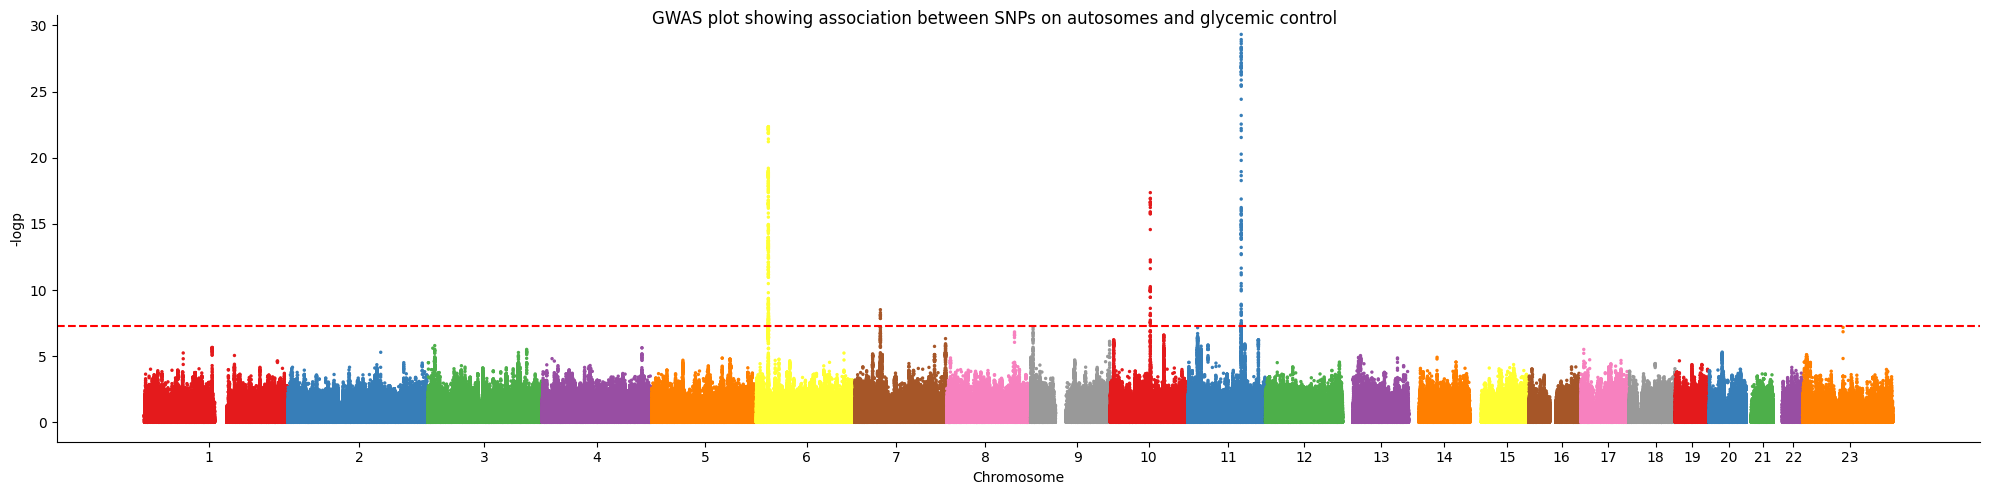

In [9]:
g = sns.relplot(
    data = df,
    x = 'cumulative_pos',
    y = '-logp',
    aspect = 4,
    hue = df['chromosome'],
    palette = 'Set1',
    linewidth=0,
    s=6,
    legend=None
)
# Adding in a statistical significance line
plt.axhline(-np.log10(5e-8), color='red', linestyle='--', label='GWAS p=5e-8')

g.ax.set_xlabel('Chromosome')
g.ax.set_xticks(df.groupby('chromosome')['cumulative_pos'].median())
g.ax.set_xticklabels(df['chromosome'].unique())
g.fig.suptitle('GWAS plot showing association between SNPs on autosomes and glycemic control')
plt.show()

## The plot looks good now!

When trying to plot based on SNP number, though, we run into another problem. We can't set the 'SNP number' dataframe equal to df.index because the index was assigned incorrectly at the start (due to the improper sorting of the dataset in the .tsv file). 

Therefore, we have to reset the index and then reassign our SNP number dataframe

In [10]:
df = df.reset_index(drop=True) # The importance of this line was discovered using AI
df['SNP Number_Updated'] = df.index # I'll name the line 'SNP Number_Updated' to differentiate with the earlier column 'SNP number'
df

,chromosome,base_pair_location,effect_allele,other_allele,beta,standard_error,effect_allele_frequency,p_value,rs_id,info,-logp,SNP number,cumulative_pos,SNP Number_Updated
0,1,49298,T,C,-0.286429,0.278038,0.00682,0.302937,rs10399793,0.04320,0.518648,0,49298,0
1,1,54353,A,C,-0.546315,1.173490,0.00971,0.641545,rs140052487,0.00161,0.192773,1,54353,1
2,1,54712,C,T,-1.266810,1.517310,0.01544,0.403780,rs773293602,0.00048,0.393855,2,54712,2
3,1,55326,C,T,2.805280,2.578980,0.04431,0.276720,rs3107975,0.00004,0.557959,3,55326,3
4,1,58814,A,G,-0.433076,0.430802,0.00370,0.314774,rs114420996,1.00000,0.502001,4,58814,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6788335,23,156007058,A,G,-0.000654,0.012252,0.39987,0.957421,chrX_156007058_A_G,0.58246,0.018897,3945923,3029544453,6788335
6788336,23,156009119,C,G,0.100992,0.060377,0.36794,0.094402,chrX_156009119_G_C,0.02615,1.025017,3945924,3029546514,6788336
6788337,23,156017071,A,G,-0.063765,0.058965,0.03553,0.279537,chrX_156017071_G_A,0.18801,0.553561,3945925,3029554466,6788337
6788338,23,156021847,G,A,0.087328,0.131210,0.05141,0.505701,chrX_156021847_A_G,0.02569,0.296106,3945926,3029559242,6788338


### The dataframe looks good now. The index is showing higher numbers than before at the end of the table which means they have been properly reset.

/var/folders/kg/qwpy89yj4qb9tjz151hk9q4r0000gn/T/ipykernel_22340/3740349877.py:1: UserWarning: 
The palette list has fewer values (22) than needed (23) and will cycle, which may produce an uninterpretable plot.
  g = sns.relplot(


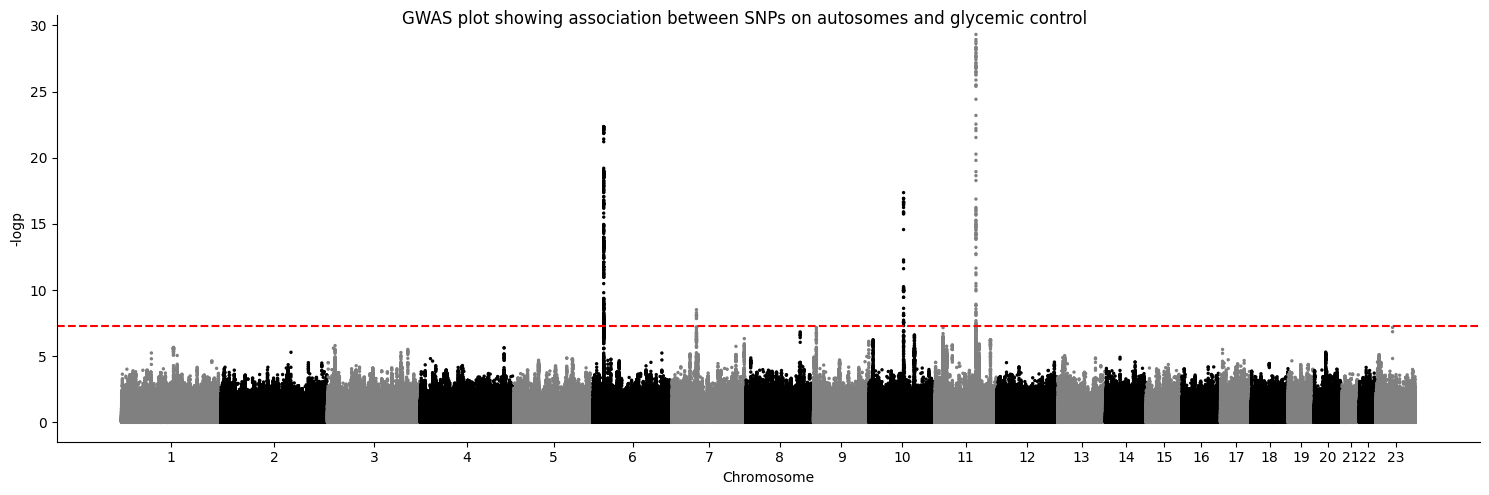

In [11]:
g = sns.relplot(
    data = df,
    x = 'SNP Number_Updated',
    y = '-logp',
    aspect = 3,
    hue = 'chromosome',
    palette = ['grey','black']*11,
    linewidth = 0,
    s = 6,
    legend = None
)
# Adding a statistical significance line:
plt.axhline(-np.log10(5e-8), color='red', linestyle='--', label=f'Genome-wide significance (p=5e-8)')


g.ax.set_xlabel('Chromosome')
g.ax.set_xticks(df.groupby('chromosome')['SNP Number_Updated'].median())
g.ax.set_xticklabels(df['chromosome'].unique())
g.fig.suptitle('GWAS plot showing association between SNPs on autosomes and glycemic control')
plt.show()

## Complete success on the manhattan plot.

The SNPs are displayed on the proper chromosome and aligned by SNP rather than position on the chromosome. The last step is to add text to identify the most significant SNPs from the study.

In [18]:
df

,chromosome,base_pair_location,effect_allele,other_allele,beta,standard_error,effect_allele_frequency,p_value,rs_id,info,-logp,SNP number,cumulative_pos,SNP Number_Updated
0,1,49298,T,C,-0.286429,0.278038,0.00682,0.302937,rs10399793,0.04320,0.518648,0,49298,0
1,1,54353,A,C,-0.546315,1.173490,0.00971,0.641545,rs140052487,0.00161,0.192773,1,54353,1
2,1,54712,C,T,-1.266810,1.517310,0.01544,0.403780,rs773293602,0.00048,0.393855,2,54712,2
3,1,55326,C,T,2.805280,2.578980,0.04431,0.276720,rs3107975,0.00004,0.557959,3,55326,3
4,1,58814,A,G,-0.433076,0.430802,0.00370,0.314774,rs114420996,1.00000,0.502001,4,58814,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6788335,23,156007058,A,G,-0.000654,0.012252,0.39987,0.957421,chrX_156007058_A_G,0.58246,0.018897,3945923,3029544453,6788335
6788336,23,156009119,C,G,0.100992,0.060377,0.36794,0.094402,chrX_156009119_G_C,0.02615,1.025017,3945924,3029546514,6788336
6788337,23,156017071,A,G,-0.063765,0.058965,0.03553,0.279537,chrX_156017071_G_A,0.18801,0.553561,3945925,3029554466,6788337
6788338,23,156021847,G,A,0.087328,0.131210,0.05141,0.505701,chrX_156021847_A_G,0.02569,0.296106,3945926,3029559242,6788338


/var/folders/kg/qwpy89yj4qb9tjz151hk9q4r0000gn/T/ipykernel_22340/3860354781.py:6: UserWarning: 
The palette list has fewer values (22) than needed (23) and will cycle, which may produce an uninterpretable plot.
  g = sns.relplot(


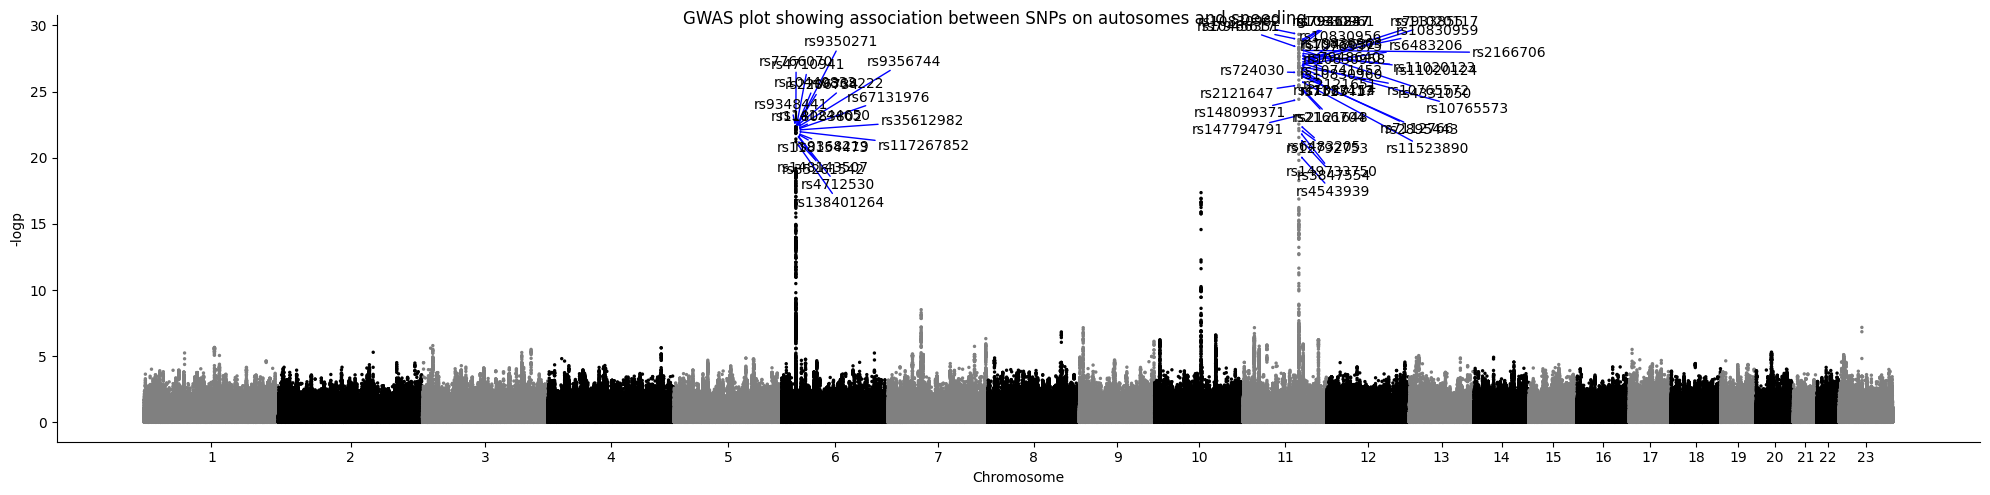

In [16]:
import adjustText
from adjustText import adjust_text

my_data = df

g = sns.relplot(
    data = my_data,
    x = 'SNP Number_Updated',
    y = '-logp',
    aspect = 4,
    hue = 'chromosome',
    palette = ['grey', 'black'] * 11,
    linewidth=0,
    s=6,
    legend=None
)

g.ax.set_xlabel('Chromosome')
g.ax.set_xticks(my_data.groupby('chromosome')['SNP Number_Updated'].median())
g.ax.set_xticklabels(df['chromosome'].unique())
g.fig.suptitle('GWAS plot showing association between SNPs on autosomes and speeding')

annotations = my_data[my_data['-logp'] > 20].apply(lambda p : g.ax.annotate(p['rs_id'], (p['SNP Number_Updated'], p['-logp'])), axis=1).to_list()
adjust_text(annotations, arrowprops = {'arrowstyle' : '->', 'color' : 'blue'})
plt.show()

## There are too many identified SNPs here due to linkage disequilibrium.

I need a way to only plot the 5 most significant SNPs per every 100,000 base pairs. This will separate linkage disequilibrium blocks from one another.

## Now to create the QQ plot and verify the results
___

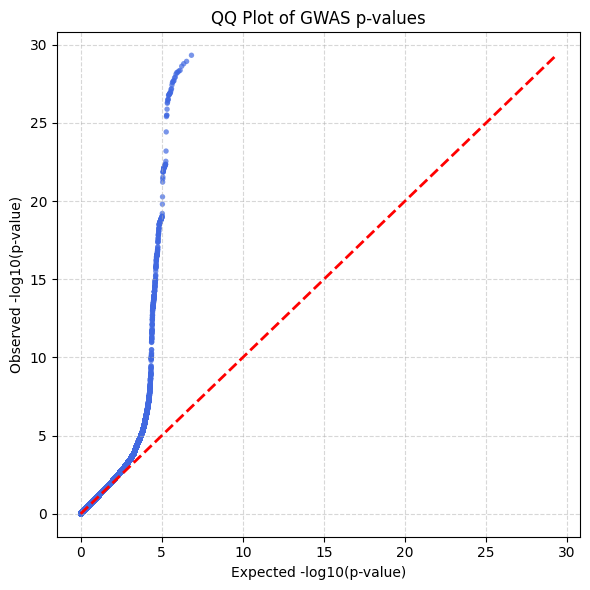

In [24]:
# Find the total number of SNPs in our data set and sort our data's SNPs by their -log10(p)
n_snps = len(df)
obs_log10 = np.sort(df['-logp'])

# Create the null distribution
expected_p = np.arange(1, n_snps + 1) / (n_snps + 1) # First create an array of all integers between 1 and our number of SNPs
# Then, divide by the total number of SNPs. (Important note: df index is 0-based so we add 1)
exp_log10 = -np.log10(expected_p[::-1]) # Turn the expected_p array into their -log10(p) and sort from smallest to largest

# Thinning the data
sig_mask = obs_log10 > 2 # Take only significant data points stored in this variable (p < 0.01)
sig_idx = np.where(sig_mask)[0] # Finds the array values for each significant SNP
non_sig_idx = np.where(~sig_mask)[0] # 

sampled_non_sig_idx = non_sig_idx[::100] # Takes every 100th point from the non-significant SNP data array

plot_idx = np.concatenate([sig_idx, sampled_non_sig_idx]) # Creates a single unified array of significant and sampled non-significant SNPs

plt.figure(figsize=(6, 6))

# Plot the thinned points
plt.scatter(
    x = exp_log10[plot_idx], 
    y = obs_log10[plot_idx], 
    color = 'royalblue', 
    s = 15,
    alpha = 0.7,
    edgecolors = 'none')

# Add the 45-degree null hypothesis line (y=x)
max_val = max(exp_log10.max(), obs_log10.max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=2)

plt.title('QQ Plot of GWAS p-values')
plt.xlabel('Expected -log10(p-value)')
plt.ylabel('Observed -log10(p-value)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## This sampling technique proved to be extraordinarily effective.

I will create a new manhattan plot to use this sampling technique and make the code more efficient while preserving all significant SNPs

/var/folders/kg/qwpy89yj4qb9tjz151hk9q4r0000gn/T/ipykernel_22340/3795294399.py:12: UserWarning: 
The palette list has fewer values (22) than needed (23) and will cycle, which may produce an uninterpretable plot.
  g = sns.relplot(


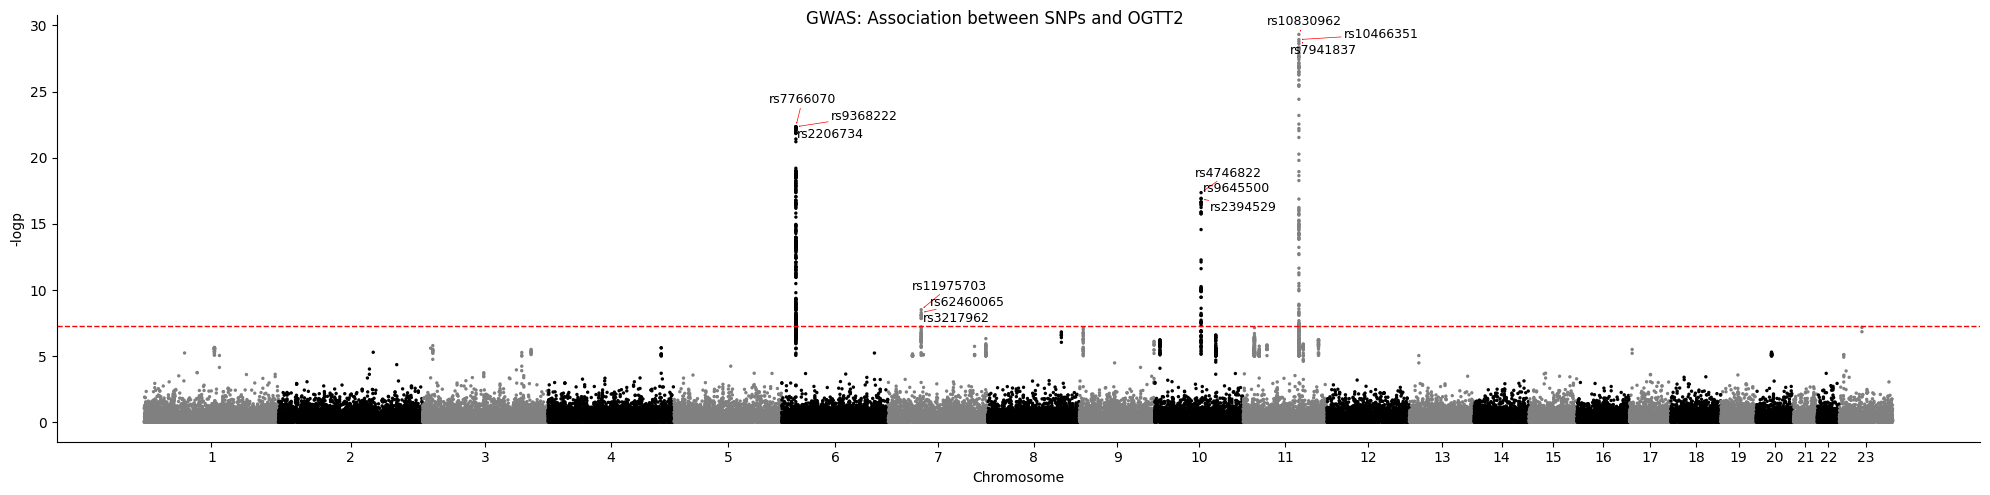

In [31]:
import adjustText
from adjustText import adjust_text

# Thinning the data
sig_snps = df[df['-logp'] > 5]
non_sig_snps = df[df['-logp'] <= 5].sample(frac=0.01, random_state=42) # Just learned that the random_state of 42 is a reference to one of my favorite books Hitchiker's Guide to the Galaxy!

# Combining
all_snps = pd.concat([sig_snps, non_sig_snps]).sort_values('SNP Number_Updated')

# Plotting
g = sns.relplot(
    data = all_snps,
    x = 'SNP Number_Updated',
    y = '-logp',
    aspect = 4,
    hue = 'chromosome',
    palette = ['grey', 'black'] * 11,
    linewidth = 0,
    s = 6,
    legend=None
)

# Finding top 3 SNPs per chromosome to label
# We group by chromosome and take the top 3 largest -logp values
top_snps = (all_snps[all_snps['-logp'] > 7.30] # Only consider genome-wide significant
            .sort_values('-logp', ascending=False) # Sort by p-value
            .groupby('chromosome') # Group by chromosome
            .head(3)) # Pick the top three SNPs from each chromosome that are above 5e-8

# Adding Annotations
texts = []
for i, row in top_snps.iterrows():
    texts.append(g.ax.text(row['SNP Number_Updated'], row['-logp'], row['rs_id'], fontsize=9))

# Styling the plot
g.ax.set_xlabel('Chromosome')
g.ax.set_xticks(df.groupby('chromosome')['SNP Number_Updated'].median())
g.ax.set_xticklabels(df['chromosome'].unique())
g.fig.suptitle('GWAS: Association between SNPs and OGTT2')

# Adding a significance line
g.ax.axhline(-np.log10(5e-8), color='red', linestyle='--', linewidth=1)

# Adjust text to prevent overlap
adjust_text(texts, arrowprops={'arrowstyle': '->', 'color': 'red', 'lw': 0.5})

plt.show()

## The plotting portion of the final project is now complete.

I have generated a readable Manhattan Plot with labeled significant SNPs and generated its associated QQ plot to verify the reasonability of the experiment. Now, I will research which gene some of these SNPs are associated with and begin plotting that gene with and without these mutations.